## Phần 1: Import thư viện & Kiểm tra OpenCV

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as hnat   

# Kiểm tra OpenCV
print(f'OpenCV version : {cv2.__version__}')
print(f'NumPy  version : {np.__version__}')

OpenCV version : 4.13.0
NumPy  version : 1.24.4


---
## Phần 2: Đọc ảnh đầu vào

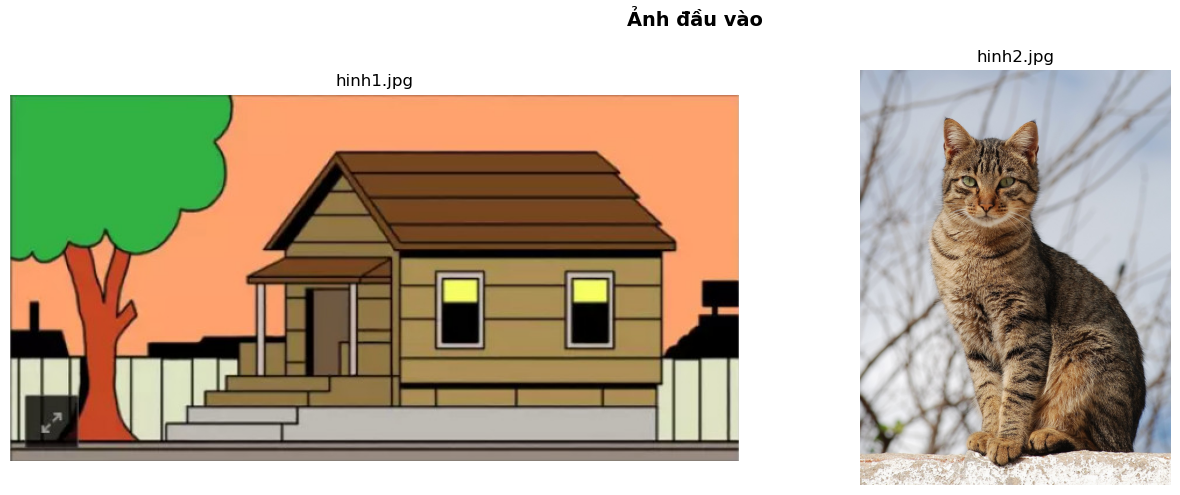

hinh1: (315, 626, 3)   hinh2: (1602, 1200, 3)


In [2]:
img  = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

fig, axes = hnat.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img[:,:,::-1]);  axes[0].set_title('hinh1.jpg'); axes[0].axis('off')
axes[1].imshow(img2[:,:,::-1]); axes[1].set_title('hinh2.jpg'); axes[1].axis('off')
hnat.suptitle('Ảnh đầu vào', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()
print(f'hinh1: {img.shape}   hinh2: {img2.shape}')

---
## Phần 3: Harris Corner Detection

**Tham khảo:** https://docs.opencv.org/3.4/dc/d0d/tutorial_py_features_harris.html

Harris đánh giá sự thay đổi cường độ ảnh theo mọi hướng:

$$R = \det(M) - k\,(\mathrm{trace}\,M)^2$$

- $R > 0$ → **corner**  |  $R < 0$ → **edge**  |  $R \approx 0$ → **flat**

Harris corners: 5510


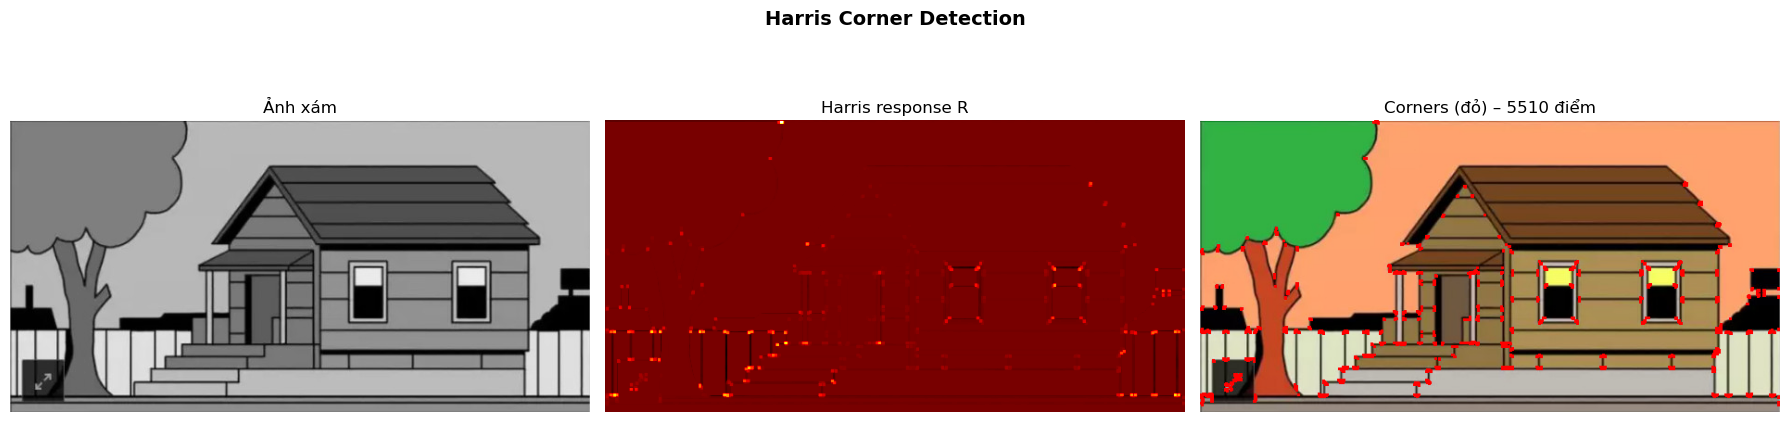

In [3]:
gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_f = np.float32(gray)

# cornerHarris(src, blockSize, ksize_sobel, k)
dst = cv2.cornerHarris(gray_f, blockSize=2, ksize=3, k=0.04)
dst = cv2.dilate(dst, None)      # phóng to corner để dễ nhìn

# Đánh dấu corners bằng màu đỏ
img_harris = img.copy()
thresh = 0.01 * dst.max()
img_harris[dst > thresh] = [0, 0, 255]

num_c = int((dst > thresh).sum())
print(f'Harris corners: {num_c}')

fig, axes = hnat.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(gray, cmap='gray');        axes[0].set_title('Ảnh xám');          axes[0].axis('off')
axes[1].imshow(dst,  cmap='hot');         axes[1].set_title('Harris response R'); axes[1].axis('off')
axes[2].imshow(img_harris[:,:,::-1]);     axes[2].set_title(f'Corners (đỏ) – {num_c} điểm'); axes[2].axis('off')
hnat.suptitle('Harris Corner Detection', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()

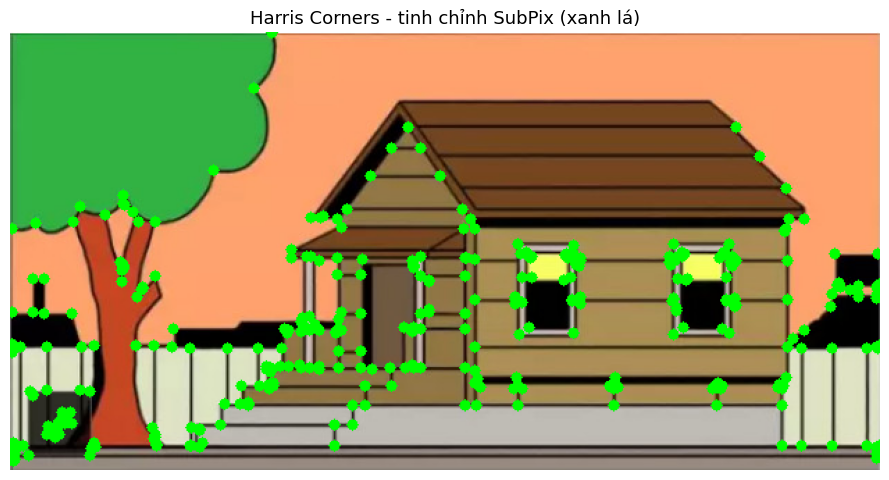

In [4]:
# Tinh chỉnh vị trí corner với cornerSubPix 

corners_yx = np.argwhere(dst > thresh)              # (y, x)
corners_f = np.ascontiguousarray(np.float32(corners_yx[:, ::-1]).reshape(-1, 1, 2))  # → (x, y)

criteria   = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.001)
corners_sub = cv2.cornerSubPix(gray, corners_f, (5,5), (-1,-1), criteria)

img_sub = img.copy()
for pt in corners_sub[::5]:          # lấy mỗi 5 điểm tránh quá dày
    x, y = int(pt[0][0]), int(pt[0][1])
    cv2.circle(img_sub, (x, y), 4, (0, 255, 0), -1)

hnat.figure(figsize=(9, 5))
hnat.imshow(img_sub[:,:,::-1])
hnat.title('Harris Corners - tinh chỉnh SubPix (xanh lá)', fontsize=13)
hnat.axis('off'); hnat.tight_layout(); hnat.show()

---
## Phần 4: Band-pass Filtering – Difference of Gaussians (DoG)

$$\mathrm{DoG}(x,y,\sigma) = G(x,y,k\sigma) - G(x,y,\sigma)$$

DoG xấp xỉ **Laplacian of Gaussian** và là nền tảng của scale-space trong SIFT.

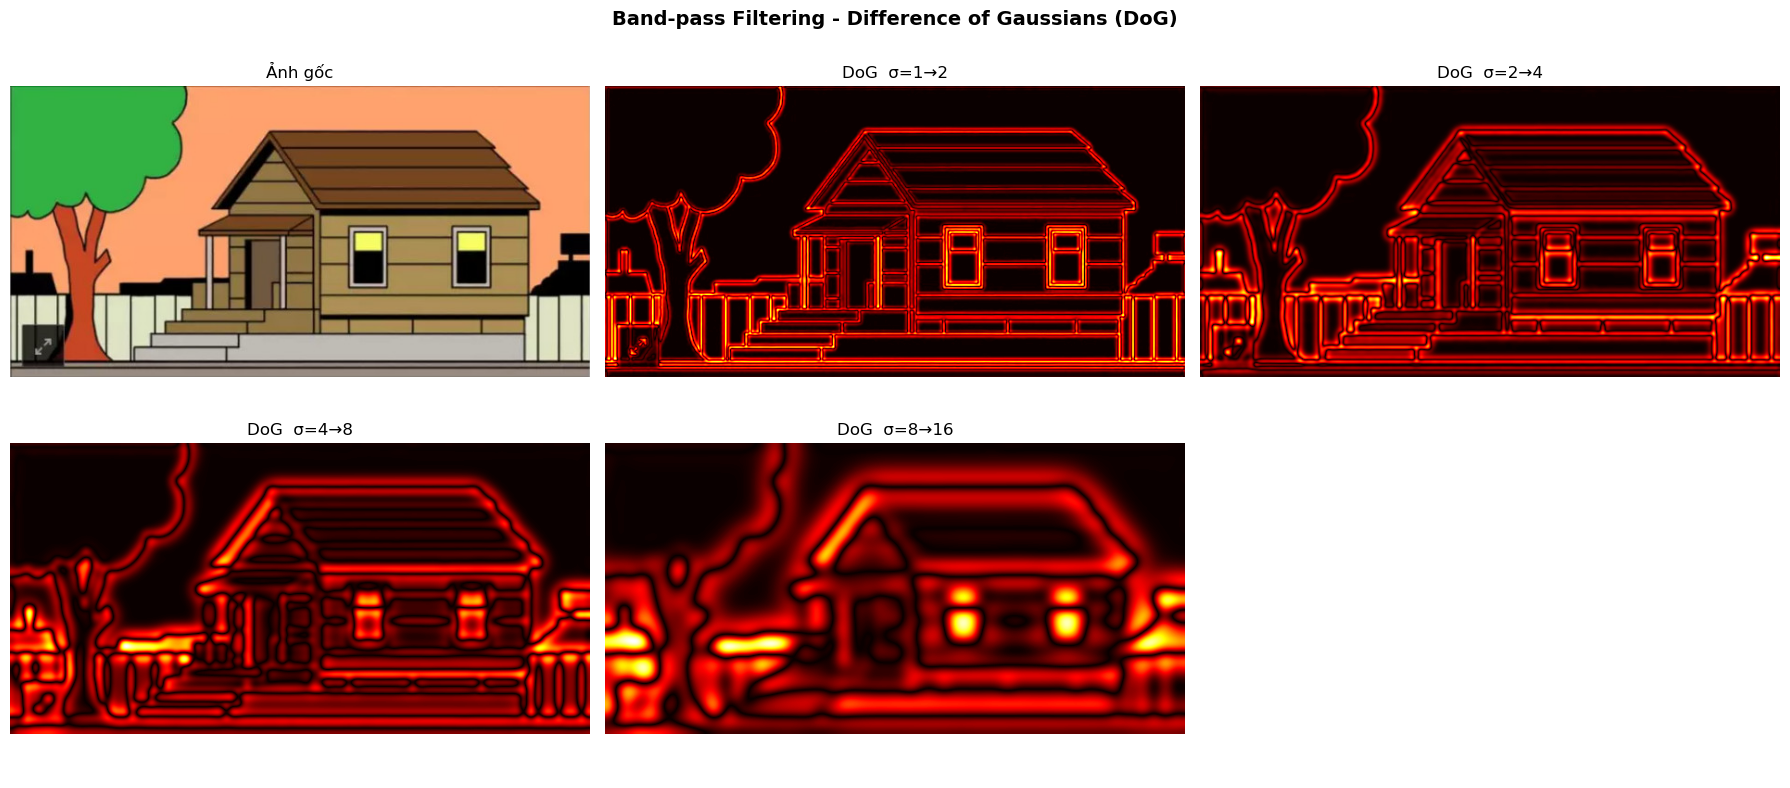

In [5]:
gray_f = img.mean(axis=2).astype(np.float32)

sigma_pairs = [(1,2), (2,4), (4,8), (8,16)]
dogs, titles = [], []

for s1, s2 in sigma_pairs:
    b1  = cv2.GaussianBlur(gray_f, (0,0), s1)
    b2  = cv2.GaussianBlur(gray_f, (0,0), s2)
    dog = np.abs(b2 - b1)
    dogs.append(dog)
    titles.append(f'DoG  σ={s1}→{s2}')

fig, axes = hnat.subplots(2, 3, figsize=(18, 8))
axes[0,0].imshow(img[:,:,::-1]); axes[0,0].set_title('Ảnh gốc'); axes[0,0].axis('off')

positions = [(0,1),(0,2),(1,0),(1,1)]
for (r,c), dog, title in zip(positions, dogs, titles):
    norm = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    axes[r,c].imshow(norm, cmap='hot'); axes[r,c].set_title(title); axes[r,c].axis('off')

axes[1,2].axis('off')
hnat.suptitle('Band-pass Filtering - Difference of Gaussians (DoG)', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()

---
## Phần 5: Automatic Scale Selection

Chọn scale tối ưu cho mỗi pixel bằng cực đại của **normalized LoG** trong scale-space:

$$\hat{\sigma}(x,y) = \arg\max_{\sigma}\; \sigma^2 |\nabla^2 G_\sigma * I|(x,y)$$

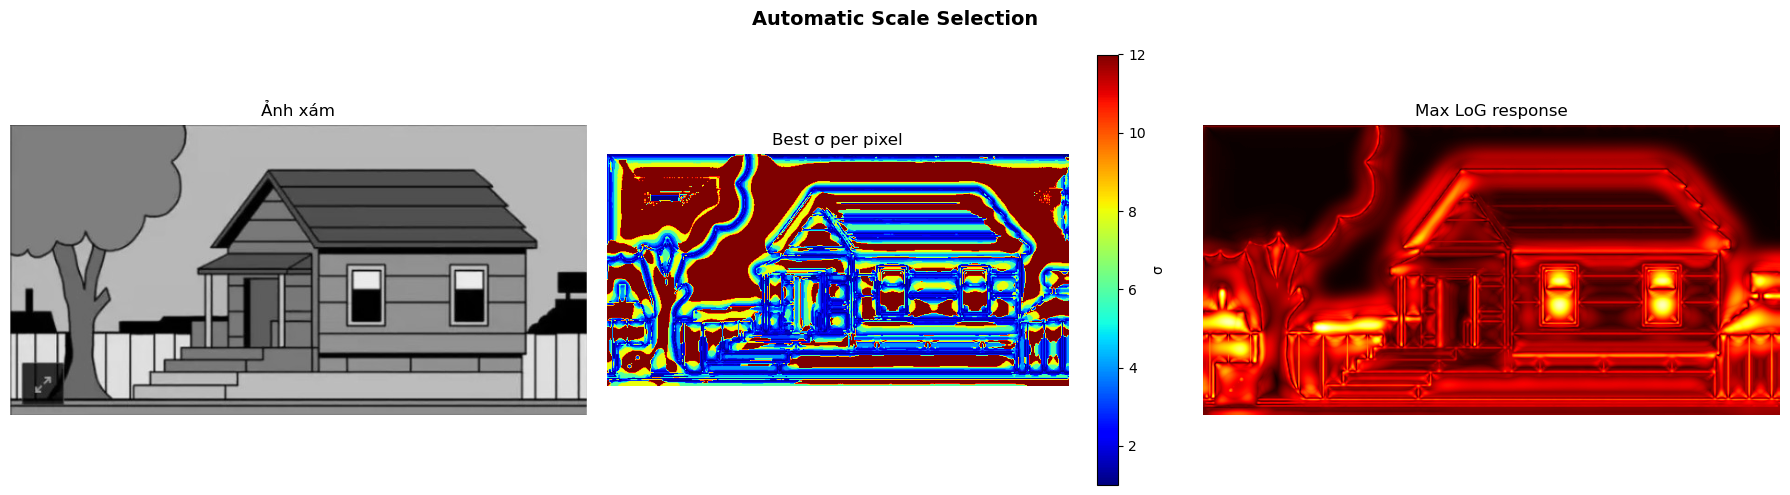

σ trung bình tốt nhất toàn ảnh: 7.33


In [6]:
gray_f = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
sigmas = [1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0]

log_stack = []
for sigma in sigmas:
    blurred = cv2.GaussianBlur(gray_f, (0,0), sigma)
    log     = cv2.Laplacian(blurred, cv2.CV_32F)
    log_stack.append((sigma**2) * np.abs(log))   # normalized LoG

scale_space  = np.stack(log_stack, axis=0)         # (S, H, W)
best_idx     = np.argmax(scale_space, axis=0)       # (H, W)
best_sigma   = np.array(sigmas)[best_idx]
max_response = np.max(scale_space, axis=0)

fig, axes = hnat.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(gray_f, cmap='gray');          axes[0].set_title('Ảnh xám');             axes[0].axis('off')
im = axes[1].imshow(best_sigma, cmap='jet')
hnat.colorbar(im, ax=axes[1], label='σ');    axes[1].set_title('Best σ per pixel');     axes[1].axis('off')
axes[2].imshow(max_response, cmap='hot');     axes[2].set_title('Max LoG response');      axes[2].axis('off')
hnat.suptitle('Automatic Scale Selection', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()
print(f'σ trung bình tốt nhất toàn ảnh: {best_sigma.mean():.2f}')

---
## Phần 6: Scale Invariant Detection – SIFT

**SIFT** bất biến với scale, rotation và một phần với biến đổi ánh sáng.

Số SIFT keypoints : 772
Kích thước descriptor: (772, 128)


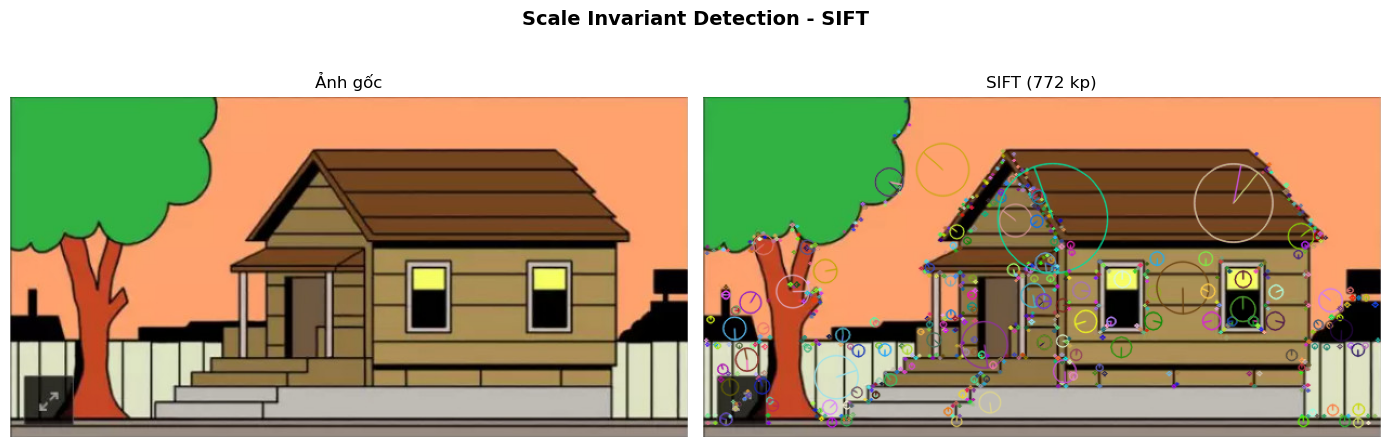

In [7]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
kp, desc = sift.detectAndCompute(gray, None)

print(f'Số SIFT keypoints : {len(kp)}')
print(f'Kích thước descriptor: {desc.shape if desc is not None else "N/A"}')

img_sift = cv2.drawKeypoints(img, kp, None,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = hnat.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img[:,:,::-1]);       axes[0].set_title('Ảnh gốc');              axes[0].axis('off')
axes[1].imshow(img_sift[:,:,::-1]);  axes[1].set_title(f'SIFT ({len(kp)} kp)'); axes[1].axis('off')
hnat.suptitle('Scale Invariant Detection - SIFT', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()

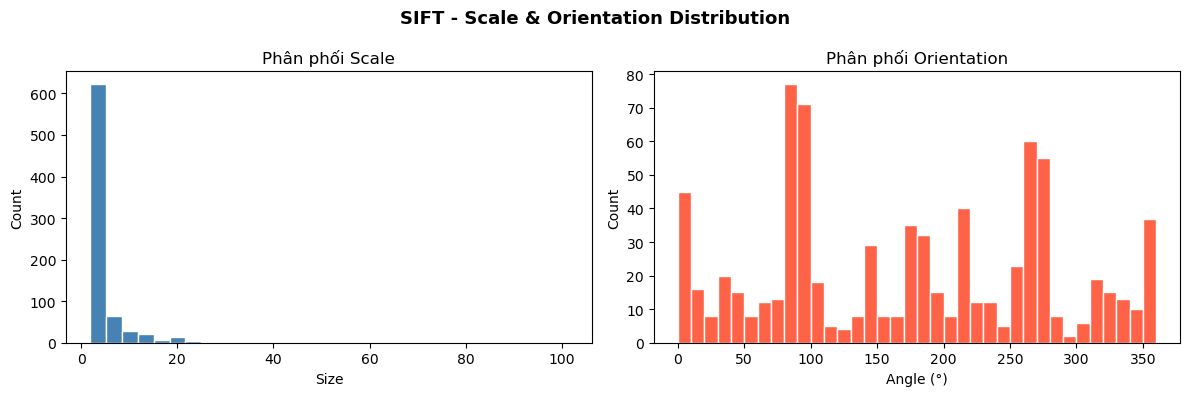

In [8]:
# Phân tích phân phối scale & orientation của SIFT keypoints

scales = [k.size  for k in kp]
angles = [k.angle for k in kp]

fig, axes = hnat.subplots(1, 2, figsize=(12, 4))
axes[0].hist(scales, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối Scale'); axes[0].set_xlabel('Size'); axes[0].set_ylabel('Count')

axes[1].hist(angles, bins=36, range=(0,360), color='tomato', edgecolor='white')
axes[1].set_title('Phân phối Orientation'); axes[1].set_xlabel('Angle (°)'); axes[1].set_ylabel('Count')

hnat.suptitle('SIFT - Scale & Orientation Distribution', fontsize=13, fontweight='bold')
hnat.tight_layout(); hnat.show()

---
## Phần 7: Scale-Space Blob Detector

Phát hiện **blob** (vùng đồng nhất dạng tròn) ở nhiều scale khác nhau.

Số blob phát hiện: 6


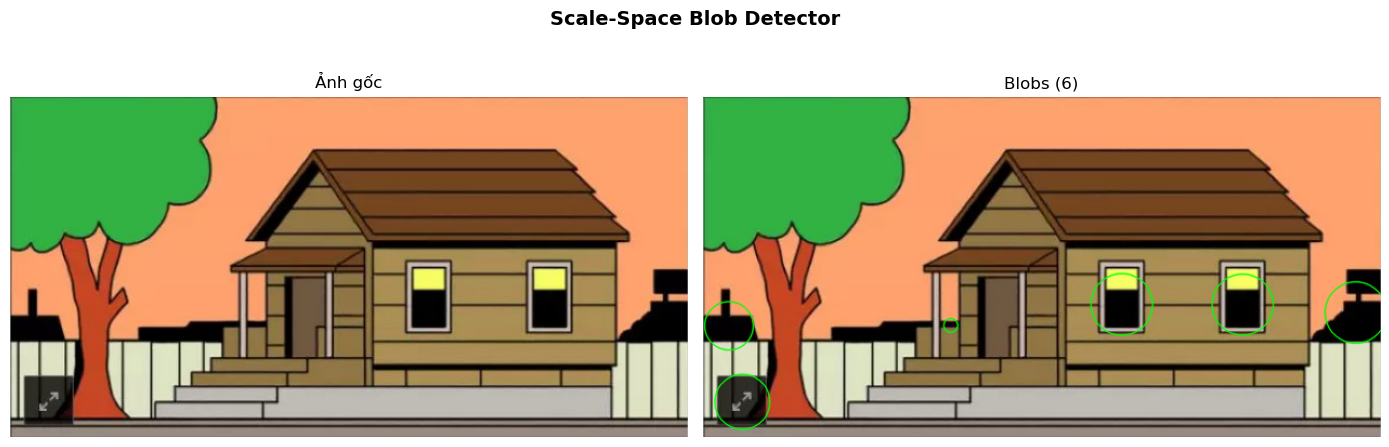

In [9]:
params = cv2.SimpleBlobDetector_Params()
params.minThreshold        = 10
params.maxThreshold        = 220
params.filterByArea        = True;  params.minArea         = 50;   params.maxArea = 60000
params.filterByCircularity = True;  params.minCircularity  = 0.2
params.filterByConvexity   = True;  params.minConvexity    = 0.4
params.filterByInertia     = True;  params.minInertiaRatio = 0.05

detector = cv2.SimpleBlobDetector_create(params)
kp_blob  = detector.detect(img)
print(f'Số blob phát hiện: {len(kp_blob)}')

img_blob = cv2.drawKeypoints(img, kp_blob, None,
                              color=(0,255,0),
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = hnat.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img[:,:,::-1]);      axes[0].set_title('Ảnh gốc');           axes[0].axis('off')
axes[1].imshow(img_blob[:,:,::-1]); axes[1].set_title(f'Blobs ({len(kp_blob)})'); axes[1].axis('off')
hnat.suptitle('Scale-Space Blob Detector', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()

---
## Phần 8: Bag-of-Words Detection  
### Bag-of-Words with SIFT + Histogram

**Pipeline BoW:**
1. Trích xuất SIFT descriptors từ tập ảnh
2. Gom nhóm thành **Visual Vocabulary** (K-Means)
3. Mã hóa mỗi ảnh bằng **histogram** visual words
4. So sánh ảnh qua khoảng cách histogram

In [10]:
# Bước 1 & 2: Xây dựng Visual Vocabulary
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import MiniBatchKMeans

def make_img(seed):
    rng = np.random.default_rng(seed)
    c   = np.full((300,400,3), 20, dtype=np.uint8)
    for _ in range(14):
        col = tuple(int(v) for v in rng.integers(70,230,3))
        x,y = int(rng.integers(0,340)), int(rng.integers(0,240))
        cv2.rectangle(c,(x,y),(x+int(rng.integers(30,80)),y+int(rng.integers(30,80))),col,-1)
        cv2.circle(c,(int(rng.integers(40,360)),int(rng.integers(40,260))),
                   int(rng.integers(15,45)),col,-1)
    return c

dataset = [img, img2] + [make_img(s) for s in range(1,7)]   # 8 ảnh

sift = cv2.SIFT_create()
all_desc, per_desc, per_kp = [], [], []

print('Trích xuất SIFT descriptors...')
for i, im in enumerate(dataset):
    g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    kp_i, d = sift.detectAndCompute(g, None)
    per_kp.append(kp_i); per_desc.append(d)
    if d is not None:
        all_desc.append(d)
        print(f'  Ảnh {i+1}: {len(kp_i):4d} keypoints')

all_desc_np = np.vstack(all_desc)
print(f'\nTổng descriptors: {all_desc_np.shape[0]}  |  Chiều: {all_desc_np.shape[1]}')

K = 40
print(f'\nXây dựng vocabulary K={K}...')
kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, n_init=5, batch_size=2048)
kmeans.fit(all_desc_np)
print('Vocabulary hoàn tất!')

Trích xuất SIFT descriptors...
  Ảnh 1:  772 keypoints
  Ảnh 2: 8189 keypoints
  Ảnh 3:   99 keypoints
  Ảnh 4:  112 keypoints
  Ảnh 5:   93 keypoints
  Ảnh 6:   98 keypoints
  Ảnh 7:   80 keypoints
  Ảnh 8:  131 keypoints

Tổng descriptors: 9574  |  Chiều: 128

Xây dựng vocabulary K=40...
Vocabulary hoàn tất!


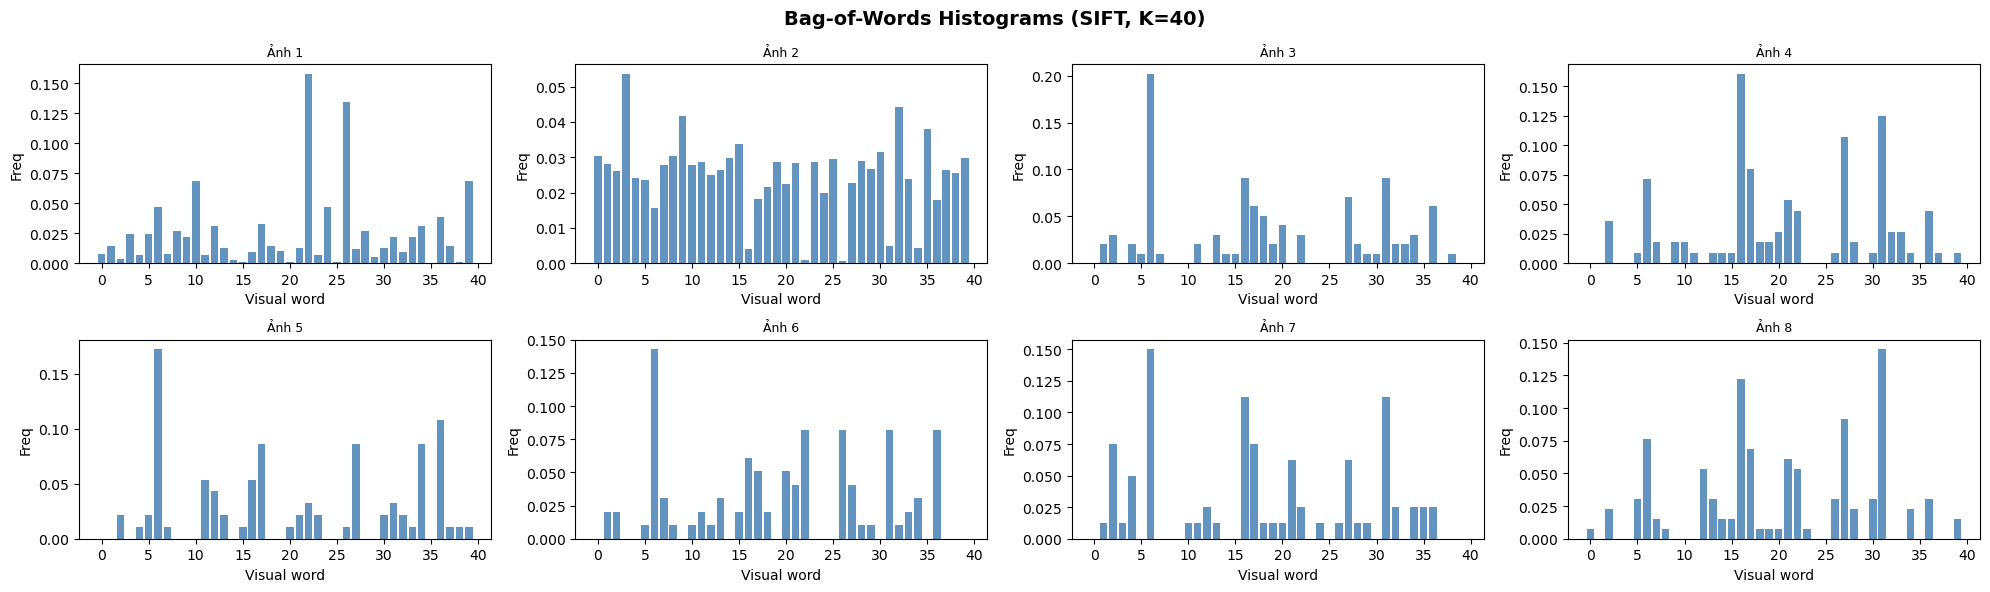

In [11]:
# Bước 3: Tạo BoW histogram cho mỗi ảnh

def bow_histogram(desc, model, k):
    if desc is None or len(desc) == 0:
        return np.zeros(k, dtype=float)
    labels = model.predict(desc)
    hist, _ = np.histogram(labels, bins=np.arange(k+1))
    return hist.astype(float) / (hist.sum() + 1e-9)

histograms = np.array([bow_histogram(d, kmeans, K) for d in per_desc])

fig, axes = hnat.subplots(2, 4, figsize=(20, 6))
for i, (hist, ax) in enumerate(zip(histograms, axes.flatten())):
    ax.bar(range(K), hist, color='steelblue', alpha=0.85)
    ax.set_title(f'Ảnh {i+1}', fontsize=9)
    ax.set_xlabel('Visual word'); ax.set_ylabel('Freq')
hnat.suptitle('Bag-of-Words Histograms (SIFT, K=40)', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()

---
## Phần 9: Image Panoramas – Ghép ảnh Panorama

**Quy trình:** SIFT → FLANN matching → Lowe's ratio test → Homography (RANSAC) → Warp & Stitch

hinh1: 772 kp   |   hinh2: 8189 kp
Good matches: 4 / 772
Inliers (RANSAC): 4


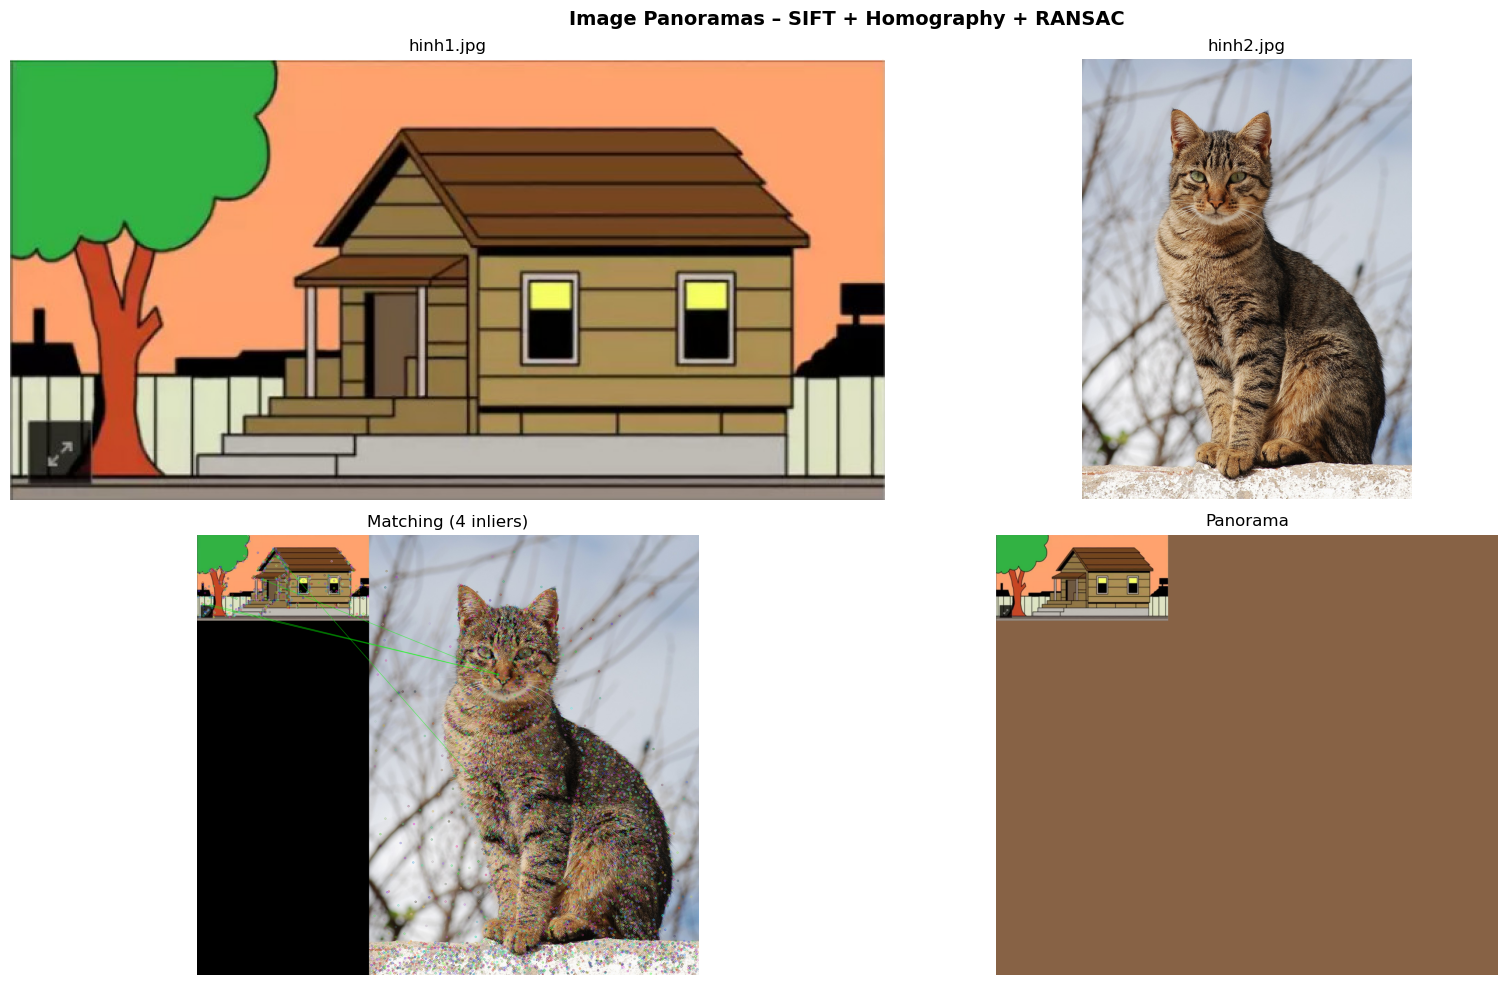

In [12]:
gray1 = cv2.cvtColor(img,  cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, d1 = sift.detectAndCompute(gray1, None)
kp2, d2 = sift.detectAndCompute(gray2, None)
print(f'hinh1: {len(kp1)} kp   |   hinh2: {len(kp2)} kp')

# FLANN Matcher
flann   = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
matches = flann.knnMatch(d1, d2, k=2)

# Lowe's ratio test
good = [m for m,n in matches if m.distance < 0.75*n.distance]
print(f'Good matches: {len(good)} / {len(matches)}')

if len(good) >= 4:
    src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    H, mask = cv2.findHomography(dst, src, cv2.RANSAC, 5.0)
    inliers  = int(mask.sum())
    print(f'Inliers (RANSAC): {inliers}')

    h1,w1 = img.shape[:2];  h2,w2 = img2.shape[:2]
    canvas_w = w1 + w2;     canvas_h = max(h1, h2)

    img2_warped = cv2.warpPerspective(img2, H, (canvas_w, canvas_h))
    panorama    = img2_warped.copy()
    panorama[0:h1, 0:w1] = img

    # Cắt vùng đen
    gp  = cv2.cvtColor(panorama, cv2.COLOR_BGR2GRAY)
    _,th = cv2.threshold(gp, 1, 255, cv2.THRESH_BINARY)
    cnts,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        xr,yr,wr,hr = cv2.boundingRect(max(cnts, key=cv2.contourArea))
        panorama = panorama[yr:yr+hr, xr:xr+wr]

    # Vẽ matches
    img_match = cv2.drawMatches(img, kp1, img2, kp2, good, None,
                                matchColor=(0,255,0),
                                matchesMask=mask.ravel().tolist(),
                                flags=cv2.DrawMatchesFlags_DEFAULT)

    fig, axes = hnat.subplots(2, 2, figsize=(18,10))
    axes[0,0].imshow(img[:,:,::-1]);       axes[0,0].set_title('hinh1.jpg');                        axes[0,0].axis('off')
    axes[0,1].imshow(img2[:,:,::-1]);      axes[0,1].set_title('hinh2.jpg');                        axes[0,1].axis('off')
    axes[1,0].imshow(img_match[:,:,::-1]); axes[1,0].set_title(f'Matching ({inliers} inliers)');    axes[1,0].axis('off')
    axes[1,1].imshow(panorama[:,:,::-1]);  axes[1,1].set_title('Panorama');                         axes[1,1].axis('off')
    hnat.suptitle('Image Panoramas – SIFT + Homography + RANSAC', fontsize=14, fontweight='bold')
    hnat.tight_layout(); hnat.show()
else:
    print(f'Không đủ matches ({len(good)}) để tính Homography.')

---
## Phần 10: Automatic Mosaicing

Stitcher lỗi (Unknown C++ exception from OpenCV code) => dùng hstack đơn giản


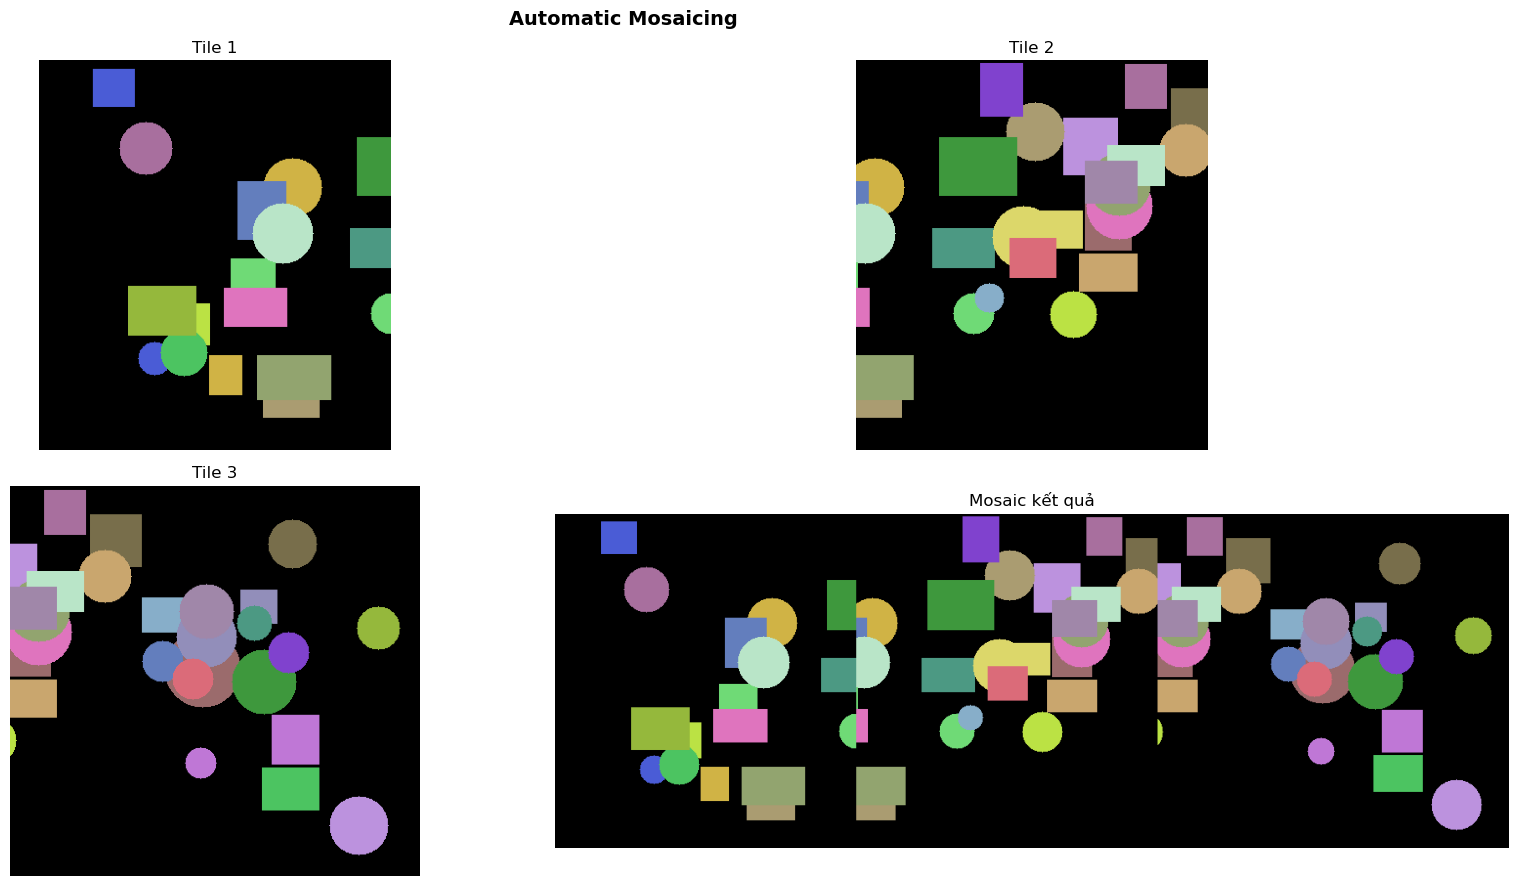

In [14]:
# Tạo ảnh panorama rộng rồi cắt thành 3 tile có overlap ~30%
wide = np.zeros((400,900,3), dtype=np.uint8)
rng  = np.random.default_rng(99)
for _ in range(25):
    c  = tuple(int(v) for v in rng.integers(60,230,3))
    x1 = int(rng.integers(0,800)); y1 = int(rng.integers(0,340))
    cv2.rectangle(wide,(x1,y1),(x1+int(rng.integers(30,80)),y1+int(rng.integers(30,60))),c,-1)
    cv2.circle(wide,(int(rng.integers(40,860)),int(rng.integers(40,360))),
               int(rng.integers(15,40)),c,-1)

tiles = [wide[:, 0:360], wide[:, 240:600], wide[:, 480:900]]

try:
    stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
    status, mosaic = stitcher.stitch(tiles)
    if status != cv2.Stitcher_OK:
        raise RuntimeError(f'Stitcher status={status}')
    print('Stitching thành công')
except Exception as e:
    print(f'Stitcher lỗi ({e}) => dùng hstack đơn giản')
    mosaic = np.hstack(tiles)

fig, axes = hnat.subplots(2, 2, figsize=(18,9))
for i,tile in enumerate(tiles):
    r,c = divmod(i,2)
    axes[r,c].imshow(tile[:,:,::-1]); axes[r,c].set_title(f'Tile {i+1}'); axes[r,c].axis('off')
axes[1,1].imshow(mosaic[:,:,::-1]); axes[1,1].set_title('Mosaic kết quả'); axes[1,1].axis('off')
hnat.suptitle('Automatic Mosaicing', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()

---
## Phần 11: Wide Baseline Stereo

So khớp hai ảnh chụp từ vị trí / góc nhìn rất khác nhau.

Wide baseline – good matches: 263


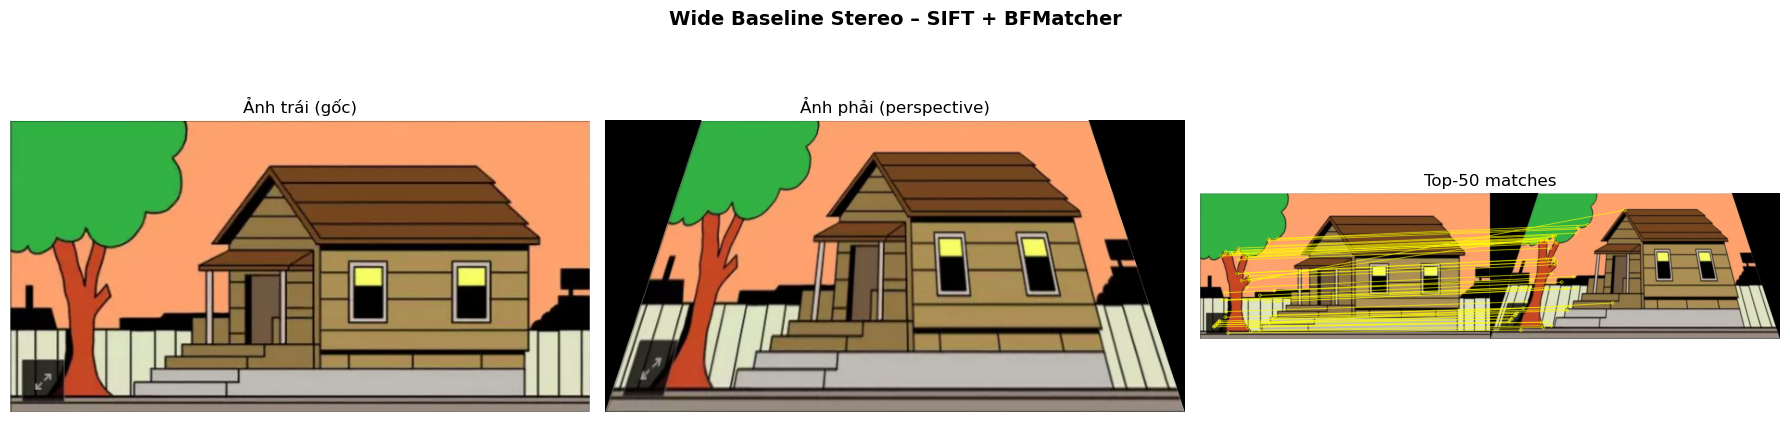

In [15]:
h0, w0 = img.shape[:2]
off    = w0 // 6
src_p  = np.float32([[0,0],[w0,0],[w0,h0],[0,h0]])
dst_p  = np.float32([[off,0],[w0-off,0],[w0,h0],[0,h0]])
M_wbs  = cv2.getPerspectiveTransform(src_p, dst_p)
img_wbs = cv2.warpPerspective(img, M_wbs, (w0,h0))

sift = cv2.SIFT_create()
kp_l, d_l = sift.detectAndCompute(cv2.cvtColor(img,     cv2.COLOR_BGR2GRAY), None)
kp_r, d_r = sift.detectAndCompute(cv2.cvtColor(img_wbs, cv2.COLOR_BGR2GRAY), None)

bf  = cv2.BFMatcher(cv2.NORM_L2)
m2  = bf.knnMatch(d_l, d_r, k=2)
good_wbs = [m for m,n in m2 if m.distance < 0.75*n.distance]
print(f'Wide baseline – good matches: {len(good_wbs)}')

img_wbs_draw = cv2.drawMatches(img, kp_l, img_wbs, kp_r,
                                good_wbs[:50], None,
                                matchColor=(0,255,255),
                                flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

fig, axes = hnat.subplots(1, 3, figsize=(18,5))
axes[0].imshow(img[:,:,::-1]);          axes[0].set_title('Ảnh trái (gốc)');         axes[0].axis('off')
axes[1].imshow(img_wbs[:,:,::-1]);      axes[1].set_title('Ảnh phải (perspective)'); axes[1].axis('off')
axes[2].imshow(img_wbs_draw[:,:,::-1]); axes[2].set_title('Top-50 matches');          axes[2].axis('off')
hnat.suptitle('Wide Baseline Stereo – SIFT + BFMatcher', fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()

---
## Phần 12: CBIR – Content-Based Image Retrieval

Tìm ảnh tương tự bằng **BoW histogram + Cosine Similarity**.

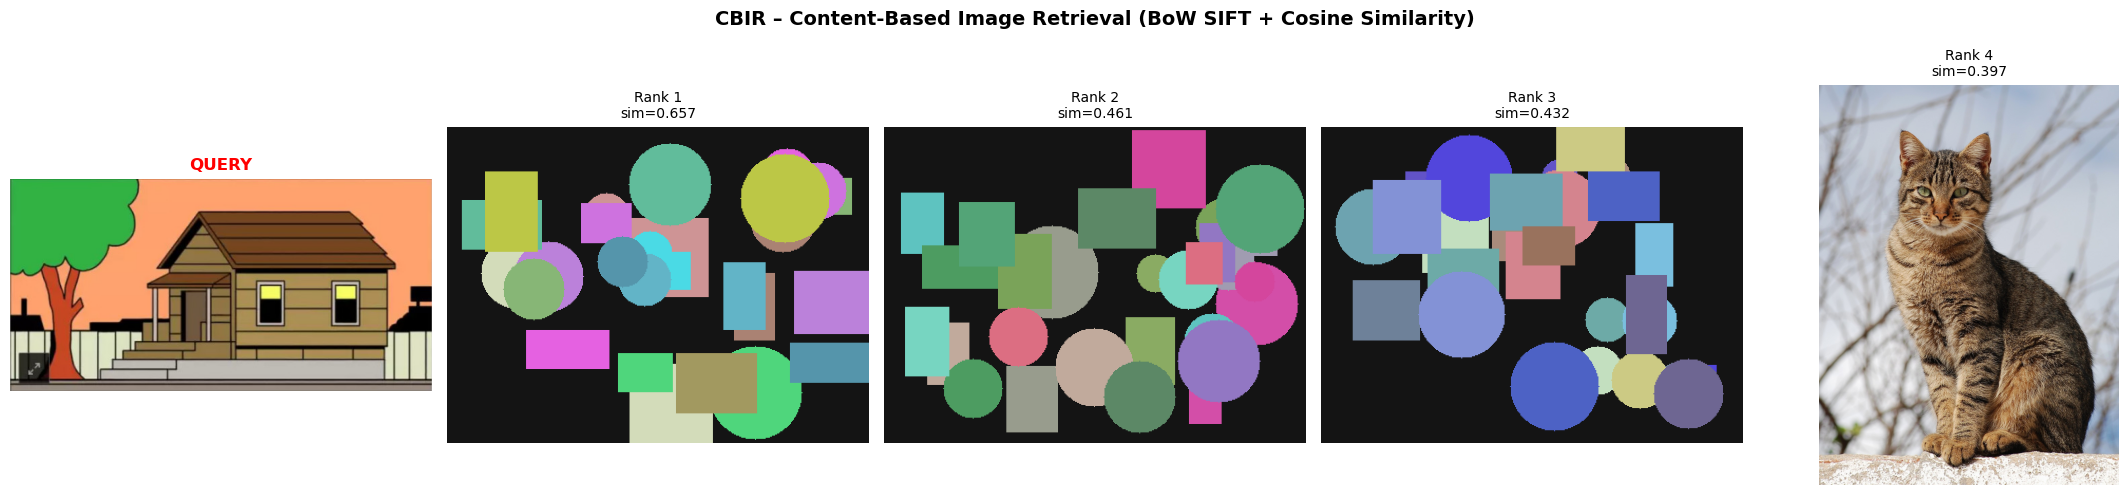


Kết quả CBIR:
  Rank 1: Ảnh 6  |  cosine similarity = 0.6574
  Rank 2: Ảnh 8  |  cosine similarity = 0.4608
  Rank 3: Ảnh 5  |  cosine similarity = 0.4322
  Rank 4: Ảnh 2  |  cosine similarity = 0.3967


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve(query_idx, hists, top_k=4):
    sims   = cosine_similarity(hists[query_idx:query_idx+1], hists)[0]
    ranked = np.argsort(sims)[::-1]
    ranked = [i for i in ranked if i != query_idx][:top_k]
    return ranked, sims[ranked]

query_idx = 0
top_idx, top_sim = retrieve(query_idx, histograms, top_k=4)

fig, axes = hnat.subplots(1, 5, figsize=(22,5))
axes[0].imshow(dataset[query_idx][:,:,::-1])
axes[0].set_title('QUERY', fontsize=12, color='red', fontweight='bold')
axes[0].axis('off')

for rank, (idx, sim) in enumerate(zip(top_idx, top_sim), 1):
    axes[rank].imshow(dataset[idx][:,:,::-1])
    axes[rank].set_title(f'Rank {rank}\nsim={sim:.3f}', fontsize=10)
    axes[rank].axis('off')

hnat.suptitle('CBIR – Content-Based Image Retrieval (BoW SIFT + Cosine Similarity)',
               fontsize=14, fontweight='bold')
hnat.tight_layout(); hnat.show()

print('\nKết quả CBIR:')
for rank,(idx,sim) in enumerate(zip(top_idx,top_sim),1):
    print(f'  Rank {rank}: Ảnh {idx+1}  |  cosine similarity = {sim:.4f}')